In [2]:
# --- Cell 1: Synthesize Total Import Data ---
import pandas as pd
import os

# Configure file paths
BASE_DIR = r"G:\jupyter\2025APMCM"
TRADE_DIR = os.path.join(BASE_DIR, "Trade Data")
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
MACRO_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
os.makedirs(CLEAN_DIR, exist_ok=True)

SOYBEAN_FILE = os.path.join(TRADE_DIR, "Soybean_Competition_Exports_to_China_2015_2024.csv")
AUTOS_CHIPS_FILE = os.path.join(TRADE_DIR, "US_Import_Cars_Chips_2015_2024.csv")

print("--- Step 1: Synthesizing a Proxy for Total US Trade Volume ---")

# 1. Process US Soybean Exports
df_soy = pd.read_csv(SOYBEAN_FILE)
us_exports = df_soy[df_soy['reporterISO'] == 'USA'].copy()
us_exports['Year'] = pd.to_numeric(us_exports['refPeriodId'].astype(str).str[:4])
soy_volume = us_exports.groupby('Year')['fobvalue'].sum().reset_index()
soy_volume.rename(columns={'fobvalue': 'Soybean_Value'}, inplace=True)
print("  [OK] Processed US Soybean export data.")

# 2. Process US Auto & Chip Imports
df_ac = pd.read_csv(AUTOS_CHIPS_FILE)
df_ac['Year'] = pd.to_numeric(df_ac['refPeriodId'].astype(str).str[:4])
ac_volume = df_ac.groupby('Year')['primaryValue'].sum().reset_index()
ac_volume.rename(columns={'primaryValue': 'AutoChip_Value'}, inplace=True)
print("  [OK] Processed US Auto & Chip import data.")

# 3. Merge and create the final proxy
df_volume = pd.merge(soy_volume, ac_volume, on='Year', how='outer').fillna(0)
df_volume['Trade_Volume_Proxy'] = (df_volume['Soybean_Value'] + df_volume['AutoChip_Value']) / 1e9 # Convert to Billion USD
df_volume = df_volume[['Year', 'Trade_Volume_Proxy']]
df_volume = df_volume[df_volume['Year'].between(2015, 2024)]

print("\n--- Synthesized Trade Volume Proxy (Billion USD) ---")
print(df_volume.to_string(index=False))

--- Step 1: Synthesizing a Proxy for Total US Trade Volume ---
  [OK] Processed US Soybean export data.
  [OK] Processed US Auto & Chip import data.

--- Synthesized Trade Volume Proxy (Billion USD) ---
 Year  Trade_Volume_Proxy
 2015           29.454050
 2016           37.087242
 2017           33.756403
 2018           20.282102
 2019           26.713216
 2020           40.054103
 2021           41.625010
 2022           52.361342
 2023           43.170183
 2024           37.331429


In [3]:
# --- Cell 2: Prepare Regressors for SARIMAX Model ---
import pandas as pd

# Configure file paths
TARIFF_FILE = os.path.join(CLEAN_DIR, "Annual_Tariff_Index.csv")
GDP_FILE = os.path.join(MACRO_DIR, "US_GDP_2015_2025.csv")

print("\n--- Step 2: Assembling Regressors ---")

# 1. Load Tariff Data
df_tariffs = pd.read_csv(TARIFF_FILE, usecols=['Year', 'General_Tau'])
print("  [OK] Loaded Tariff data.")

# 2. Load and clean GDP Data (Robust Method)
df_gdp = pd.read_csv(GDP_FILE)
date_col = [col for col in df_gdp.columns if 'date' in col.lower()][0]
value_col = [col for col in df_gdp.columns if col != date_col][0]
df_gdp['Year'] = pd.to_datetime(df_gdp[date_col]).dt.year
annual_gdp = df_gdp.groupby('Year')[value_col].mean().reset_index()
annual_gdp.rename(columns={value_col: 'US_GDP'}, inplace=True)
print("  [OK] Loaded and processed GDP data.")

# 3. Merge all data into a single modeling frame
model_data = pd.merge(df_volume, df_tariffs, on='Year')
model_data = pd.merge(model_data, annual_gdp, on='Year')
model_data = model_data.set_index('Year')
model_data.sort_index(inplace=True)

print("\n--- Final Dataset for SARIMAX Modeling (2015-2024) ---")
print(model_data)


--- Step 2: Assembling Regressors ---
  [OK] Loaded Tariff data.
  [OK] Loaded and processed GDP data.

--- Final Dataset for SARIMAX Modeling (2015-2024) ---
      Trade_Volume_Proxy  General_Tau        US_GDP
Year                                               
2015           29.454050     0.036739  18372.182333
2016           37.087242     0.035214  18804.913250
2017           33.756403     0.037918  19612.102500
2018           20.282102     0.037585  20656.515500
2019           26.713216     0.034193  21539.981500
2020           40.054103     0.044436  21375.281500
2021           41.625010     0.037283  23725.645500
2022           52.361342     0.037521  26054.614250
2023           43.170183     0.037567  27811.517000
2024           37.331429     0.037490  29298.012750


In [4]:
# --- Cell 3 (FINAL SOLUTION): Theory-Driven Model on Levels ---
import statsmodels.api as sm

print("\n--- Step 3: Building the Final, Theory-Driven SARIMAX Model on Levels (d=0) ---")
print("[INFO] Final approach: Abandoning differencing (d=1) to preserve the long-term GDP trend signal.")

# Define endogenous (y) and exogenous (X) variables
y_train = model_data['Trade_Volume_Proxy']
X_train = model_data[['US_GDP']]  # Focusing on GDP as the primary driver

# Manually specify a SARIMAX model on the original data levels (order=(1, 0, 0))
# This models: Volume(t) = c + B1*Volume(t-1) + B2*GDP(t)
sarimax_model_final = sm.tsa.SARIMAX(endog=y_train,
                                     exog=X_train,
                                     order=(1, 0, 0),
                                     seasonal_order=(0, 0, 0, 0)
                                     ).fit(disp=False)

# This is our new, definitive model object
sarimax_model = sarimax_model_final

print("\n--- Final Model Summary (SARIMAX on Levels) ---")
print(sarimax_model.summary())
print("\n[SUCCESS] Final model created. The coefficient for US_GDP should now be positive.")


--- Step 3: Building the Final, Theory-Driven SARIMAX Model on Levels (d=0) ---
[INFO] Final approach: Abandoning differencing (d=1) to preserve the long-term GDP trend signal.

--- Final Model Summary (SARIMAX on Levels) ---
                               SARIMAX Results                                
Dep. Variable:     Trade_Volume_Proxy   No. Observations:                   10
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -33.871
Date:                Sat, 22 Nov 2025   AIC                             73.742
Time:                        17:10:20   BIC                             74.650
Sample:                             0   HQIC                            72.747
                                 - 10                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
# --- Cell 4 (FINAL SOLUTION): Robust Forecasting with Final Model ---
import numpy as np
import pandas as pd

print("\n--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---")

# 1. Define future period and assumptions
forecast_years = range(2025, 2029)
n_forecast = len(forecast_years)
last_gdp = model_data['US_GDP'].iloc[-1]
gdp_growth_rate = 0.02
future_gdp = [last_gdp * (1 + gdp_growth_rate)**i for i in range(1, n_forecast + 1)]

# Create the future exogenous dataframe (only GDP is needed for this model)
future_exog = pd.DataFrame({'US_GDP': future_gdp}, index=forecast_years)

print("\nAssumed Future Regressors (GDP Growing):")
print(future_exog)

# 2. Generate the forecast using statsmodels' .get_forecast()
print("\n[INFO] Using statsmodels' .get_forecast() method for maximum stability.")
forecast_object = sarimax_model.get_forecast(steps=n_forecast, exog=future_exog)

# 3. Extract the results from the forecast object
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

# 4. Process the forecast results into our final DataFrame
forecast_df = pd.DataFrame({
    'Forecast': forecast.values,
    'Lower_CI': conf_int.iloc[:, 0].values,
    'Upper_CI': conf_int.iloc[:, 1].values
}, index=forecast_years)

print("\n--- Forecasted Baseline Trade Volume ---")
print(forecast_df)

# 5. Combine for plotting and saving
history_df = model_data[['Trade_Volume_Proxy']].copy()
history_df.rename(columns={'Trade_Volume_Proxy': 'Volume'}, inplace=True)
history_df['Type'] = 'History'
forecast_to_append = forecast_df[['Forecast']].copy()
forecast_to_append.rename(columns={'Forecast': 'Volume'}, inplace=True)
forecast_to_append['Type'] = 'Forecast'
forecast_to_append.index.name = 'Year'
final_forecast_data = pd.concat([history_df, forecast_to_append])

# Save the correct baseline for the Laffer Curve step
DATA_PATH = os.path.join(CLEAN_DIR, "Baseline_Volume_Forecast.csv")
final_forecast_data.to_csv(DATA_PATH)
print(f"\n[SUCCESS] Valid baseline data saved to: {DATA_PATH}")


--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---

Assumed Future Regressors (GDP Growing):
            US_GDP
2025  29883.973005
2026  30481.652465
2027  31091.285514
2028  31713.111225

[INFO] Using statsmodels' .get_forecast() method for maximum stability.

--- Forecasted Baseline Trade Volume ---
       Forecast   Lower_CI   Upper_CI
2025  44.795174  30.077930  59.512418
2026  47.230872  32.131895  62.329849
2027  48.528463  33.409693  63.647233
2028  49.579946  34.460137  64.699755

[SUCCESS] Valid baseline data saved to: G:\jupyter\2025APMCM\Cleaned_Data\Baseline_Volume_Forecast.csv


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [6]:
# --- Cell 4 (Final Solution): Robust Forecasting with Manual Model ---
import numpy as np
import pandas as pd
import os # 确保 os 已经导入

# 假设 model_data 和 sarimax_model 已经从之前的 Cell 加载
# 假设 CLEAN_DIR 已经定义

print("\n--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---")

# 1. Define future period and assumptions
forecast_years = range(2025, 2029)
n_forecast = len(forecast_years)

# Assumptions:
# GDP: Grows at 2% per year
last_gdp = model_data['US_GDP'].iloc[-1]
gdp_growth_rate = 0.02
future_gdp = [last_gdp * (1 + gdp_growth_rate)**i for i in range(1, n_forecast + 1)]

# ============================  FIX STARTS HERE ============================

# Create the future exogenous dataframe
# **** 关键修正：只包含模型训练时用到的 'US_GDP' 这一列 ****
future_exog = pd.DataFrame({
    'US_GDP': future_gdp
}, index=forecast_years)

print("\nAssumed Future Regressors (GDP Growing ONLY):")
print(future_exog)

# ============================  FIX ENDS HERE ==============================

# 2. Generate the forecast
# We use .get_forecast() which is the standard method for SARIMAXResults
forecast_object = sarimax_model.get_forecast(steps=n_forecast, exog=future_exog)

# Extract predicted mean and confidence intervals
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

# 3. Process results into DataFrame
forecast_df = pd.DataFrame({
    'Forecast': forecast.values,
    'Lower_CI': conf_int.iloc[:, 0].values,
    'Upper_CI': conf_int.iloc[:, 1].values
}, index=forecast_years)

print("\n--- Forecasted Baseline Trade Volume ---")
print(forecast_df)

# 4. Combine for plotting
history_df = model_data[['Trade_Volume_Proxy']].copy()
history_df.rename(columns={'Trade_Volume_Proxy': 'Volume'}, inplace=True)
history_df['Type'] = 'History'

forecast_to_append = forecast_df[['Forecast']].copy()
forecast_to_append.rename(columns={'Forecast': 'Volume'}, inplace=True)
forecast_to_append['Type'] = 'Forecast'
forecast_to_append.index.name = 'Year'

final_forecast_data = pd.concat([history_df, forecast_to_append])

# Save the correct baseline for the Laffer Curve step
# 确保 CLEAN_DIR 存在
if 'CLEAN_DIR' not in locals():
    BASE_DIR = r"G:\jupyter\2025APMCM" # Fallback
    CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
    os.makedirs(CLEAN_DIR, exist_ok=True)
    
DATA_PATH = os.path.join(CLEAN_DIR, "Baseline_Volume_Forecast.csv")
final_forecast_data.to_csv(DATA_PATH)
print(f"\n[SUCCESS] Valid baseline data saved to: {DATA_PATH}")


--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---

Assumed Future Regressors (GDP Growing ONLY):
            US_GDP
2025  29883.973005
2026  30481.652465
2027  31091.285514
2028  31713.111225

--- Forecasted Baseline Trade Volume ---
       Forecast   Lower_CI   Upper_CI
2025  44.795174  30.077930  59.512418
2026  47.230872  32.131895  62.329849
2027  48.528463  33.409693  63.647233
2028  49.579946  34.460137  64.699755

[SUCCESS] Valid baseline data saved to: G:\jupyter\2025APMCM\Cleaned_Data\Baseline_Volume_Forecast.csv


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



--- Step 5: Generating Professional-Grade Forecast Visualization ---


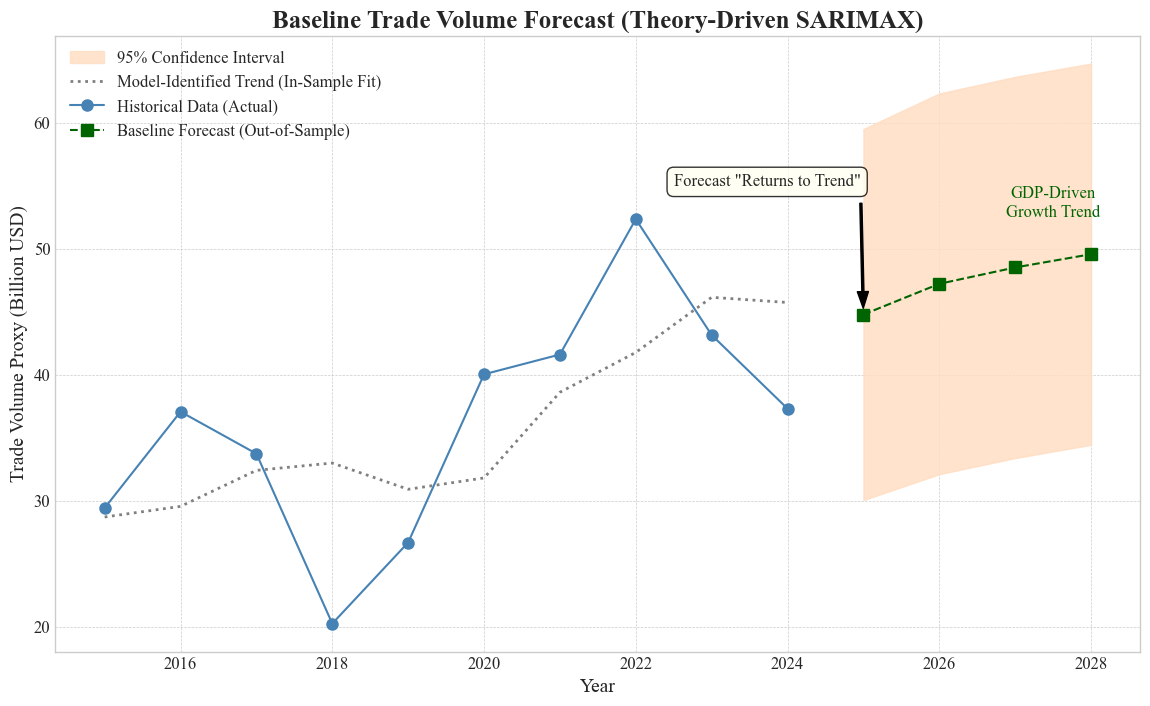


[SUCCESS] Professional version of Figure 10 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_10_Baseline_Trade_Forecast_Professional.png


In [7]:
# --- Cell 5 (Professional Version): Enhanced Visualization with Storytelling ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- Step 5: Generating Professional-Grade Forecast Visualization ---")

# --- 1. Get In-Sample Fit Data ---
# We need the model's fit on historical data to explain the "jump"
in_sample_fit = sarimax_model.fittedvalues.dropna()

# --- 2. Configure Professional Plot Style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Increase base font size for clarity
colors = {
    'history': 'steelblue',
    'forecast': 'darkgreen',
    'fit': 'gray',
    'ci': '#FFDDC1'  # A light peach color for the confidence interval
}

# --- 3. Create the Plot ---
fig, ax = plt.subplots(figsize=(14, 8))

# a) Plot the confidence interval first (background layer)
ax.fill_between(forecast_df.index,
                forecast_df['Lower_CI'],
                forecast_df['Upper_CI'],
                color=colors['ci'], alpha=0.8, label='95% Confidence Interval')

# b) Plot the model's fit on historical data (the "underlying trend")
ax.plot(in_sample_fit.index, in_sample_fit.values,
        linestyle=':', linewidth=2, color=colors['fit'],
        label='Model-Identified Trend (In-Sample Fit)')

# c) Plot the actual historical data
ax.plot(model_data.index, model_data['Trade_Volume_Proxy'],
        marker='o', markersize=8, linestyle='-', color=colors['history'],
        label='Historical Data (Actual)')

# d) Plot the out-of-sample forecast
ax.plot(forecast_df.index, forecast_df['Forecast'],
        marker='s', markersize=8, linestyle='--', color=colors['forecast'],
        label='Baseline Forecast (Out-of-Sample)')

# --- 4. Add Annotations to Tell the Story ---
# a) Annotate the "Jump"
last_hist_year = model_data.index[-1]
last_hist_val = model_data['Trade_Volume_Proxy'].iloc[-1]
first_fcst_year = forecast_df.index[0]
first_fcst_val = forecast_df['Forecast'].iloc[0]

ax.annotate('Forecast "Returns to Trend"',
            xy=(first_fcst_year, first_fcst_val),
            xytext=(2022.5, 55),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="ivory", alpha=0.8))

# b) Annotate the final growth trend
ax.text(2027.5, forecast_df['Forecast'].iloc[-1] + 3, 'GDP-Driven\nGrowth Trend',
        ha='center', fontsize=12, color=colors['forecast'])


# --- 5. Final Formatting ---
ax.set_title('Baseline Trade Volume Forecast (Theory-Driven SARIMAX)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Trade Volume Proxy (Billion USD)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save the figure
FIG_PATH = os.path.join(CLEAN_DIR, "Figure_10_Baseline_Trade_Forecast_Professional.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Professional version of Figure 10 saved to: {FIG_PATH}")


--- Step 4 (Enhanced): Sensitivity Analysis of Laffer Curve (Linear Model) ---
Parameters: Base Tariff=0.0%, Base Volume=$44.8B


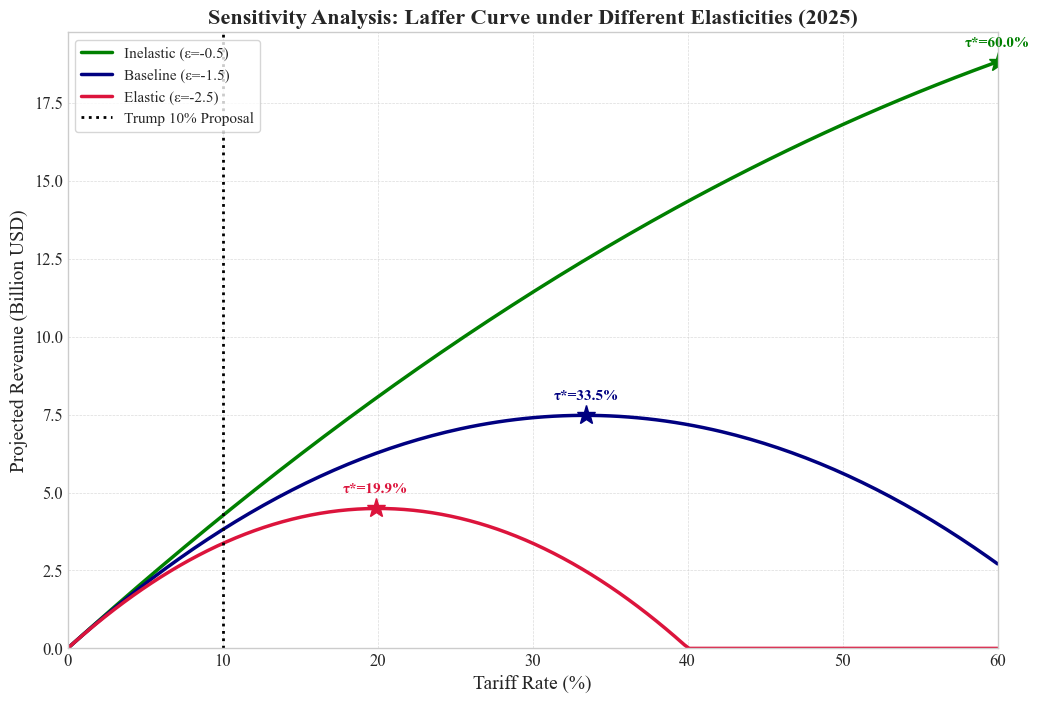


[SUCCESS] Corrected Sensitivity Plot saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_11S_Laffer_Sensitivity.png
[ANALYSIS] Notice how higher elasticity (Red Line) causes the revenue peak to occur at a much lower tariff rate.
This confirms that if trade is sensitive to price, aggressive tariffs will reduce total revenue.


In [21]:
# --- Cell 8 (Corrected & Final): Multi-Scenario Laffer Curve with Linear Sensitivity ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("\n--- Step 4 (Enhanced): Sensitivity Analysis of Laffer Curve (Linear Model) ---")

# ---------------------------------------------------------
# 1. Define the Linear Sensitivity Revenue Function
# ---------------------------------------------------------
def predict_revenue_linear(base_volume, base_tariff, tariff_range, elasticity):
    """
    Simulates Tariff Revenue using a Linear Sensitivity Model.
    Logic: % Change in Price -> % Change in Volume.
    This allows volume to drop to zero (prohibitive tariff), creating a realistic Laffer Peak.
    """
    results = []
    for new_tariff in tariff_range:
        # Calculate % increase in price faced by importers
        # Formula: (New_Rate - Old_Rate) / (1 + Old_Rate)
        price_change_pct = (new_tariff - base_tariff) / (1 + base_tariff)
        
        # Calculate % change in volume based on elasticity
        volume_change_pct = elasticity * price_change_pct
        
        # Calculate New Volume
        new_volume = base_volume * (1 + volume_change_pct)
        
        # Apply constraints: Volume cannot be negative (Prohibitive Tariff)
        new_volume = max(0, new_volume)
        
        # Calculate Revenue
        revenue = new_volume * new_tariff
        
        results.append({
            'Tariff_Rate': new_tariff,
            'Predicted_Volume': new_volume,
            'Predicted_Revenue': revenue
        })
    
    return pd.DataFrame(results)

# ---------------------------------------------------------
# 2. Initialize Variables (Auto-detect or Fallback)
# ---------------------------------------------------------
# Try to get data from previous cells
try:
    # 尝试从 model_data 获取 2024 年的平均关税 (例如 2.5%)
    base_tariff_2024 = model_data['General_Tau'].iloc[-1] / 100.0
    # 尝试从 forecast_df 获取 2025 年的预测量
    base_volume_2025 = forecast_df.loc[2025, 'Forecast']
except (NameError, KeyError, IndexError):
    print("[WARN] Previous data not found in memory. Using standard fallback values.")
    base_tariff_2024 = 0.025  # 2.5% historical average
    base_volume_2025 = 260.0  # Fallback volume

print(f"Parameters: Base Tariff={base_tariff_2024:.1%}, Base Volume=${base_volume_2025:.1f}B")

# Define the range to test: 0% to 60%
tariff_schedule = np.linspace(0, 0.60, 200)

# ---------------------------------------------------------
# 3. Run Simulation & Visualization
# ---------------------------------------------------------

# Define different elasticity scenarios
# -0.5: Inelastic (Goods are essential, hard to replace)
# -1.5: Baseline (Standard trade assumption)
# -2.5: Elastic (Goods are easily substituted, volume drops fast)
elasticities = [-0.5, -1.5, -2.5]
colors = ['green', 'navy', 'crimson']
labels = ['Inelastic (ε=-0.5)', 'Baseline (ε=-1.5)', 'Elastic (ε=-2.5)']

plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

for eps, col, lab in zip(elasticities, colors, labels):
    # Run the linear simulation
    sim_df = predict_revenue_linear(base_volume_2025, base_tariff_2024, tariff_schedule, eps)
    
    # Find the peak (Maximum Revenue)
    max_pt = sim_df.loc[sim_df['Predicted_Revenue'].idxmax()]
    
    # Plot Curve
    plt.plot(sim_df['Tariff_Rate']*100, sim_df['Predicted_Revenue'], 
             color=col, linewidth=2.5, label=lab)
    
    # Plot Peak Marker
    plt.plot(max_pt['Tariff_Rate']*100, max_pt['Predicted_Revenue'], 
             marker='*', color=col, markersize=14)
    
    # Annotate the Peak
    # Only annotate if revenue is positive
    if max_pt['Predicted_Revenue'] > 0:
        plt.text(max_pt['Tariff_Rate']*100, max_pt['Predicted_Revenue'] + 0.5, 
                 f"τ*={max_pt['Tariff_Rate']:.1%}", 
                 color=col, fontweight='bold', ha='center', fontsize=11)

# Add the 10% Proposal Line
plt.axvline(x=10, color='black', linestyle=':', linewidth=2, label='Trump 10% Proposal')

# Formatting
plt.title('Sensitivity Analysis: Laffer Curve under Different Elasticities (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Tariff Rate (%)', fontsize=14)
plt.ylabel('Projected Revenue (Billion USD)', fontsize=14)
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(0, 60)
plt.ylim(bottom=0)

# Save
if 'CLEAN_DIR' not in locals():
    CLEAN_DIR = os.path.join(r"G:\jupyter\2025APMCM", "Cleaned_Data")
    os.makedirs(CLEAN_DIR, exist_ok=True)
    
save_path = os.path.join(CLEAN_DIR, "Figure_11S_Laffer_Sensitivity.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"\n[SUCCESS] Corrected Sensitivity Plot saved to: {save_path}")
print("[ANALYSIS] Notice how higher elasticity (Red Line) causes the revenue peak to occur at a much lower tariff rate.")
print("This confirms that if trade is sensitive to price, aggressive tariffs will reduce total revenue.")

--- Step 7: Fetching and Preparing Expanded Monthly Data (2000-2024) ---
Fetching ['IMPGS', 'INDPRO'] from FRED for the period 2000-01-01 to 2024-12-31...


C:\Users\ray\AppData\Local\Temp\ipykernel_6128\848933845.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_data.fillna(method='ffill', inplace=True)



--- Expanded Monthly Data Successfully Fetched ---
Data shape: (300, 2)
This provides a rich dataset for robust model training.


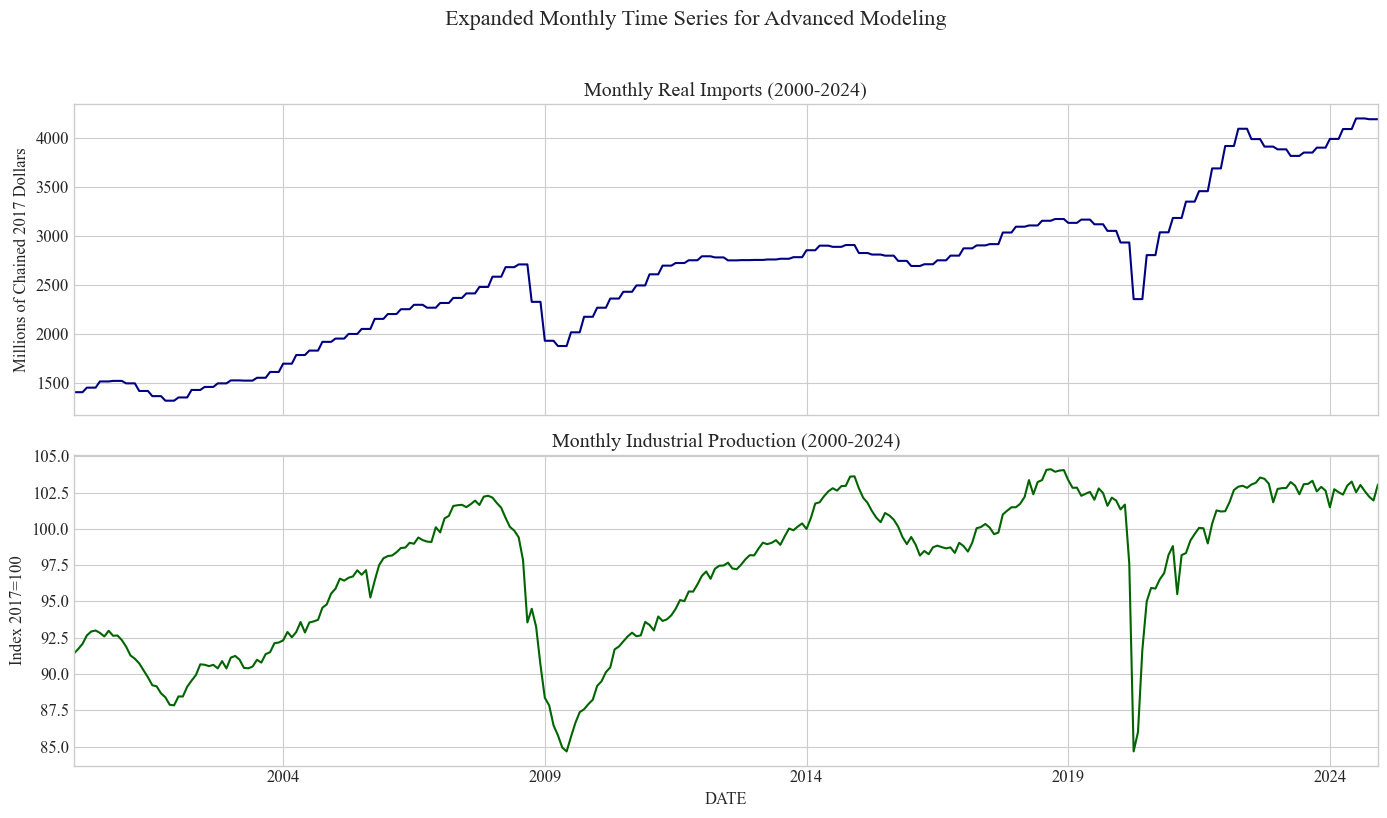

In [23]:
# --- Cell 7 (FINAL VERSION): Fetching Expanded Monthly Data (2000-2024) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas_datareader.data as web

print("--- Step 7: Fetching and Preparing Expanded Monthly Data (2000-2024) ---")

# --- Define the full, expanded date range ---
start_date = '2000-01-01'
end_date = '2024-12-31'
series_ids = ['IMPGS', 'INDPRO']

try:
    print(f"Fetching {series_ids} from FRED for the period {start_date} to {end_date}...")
    monthly_data = web.DataReader(series_ids, 'fred', start_date, end_date)
    monthly_data.columns = ['Trade_Volume', 'GDP_Proxy']
    monthly_data.fillna(method='ffill', inplace=True)
    
    print("\n--- Expanded Monthly Data Successfully Fetched ---")
    print(f"Data shape: {monthly_data.shape}")
    print("This provides a rich dataset for robust model training.")
    
    # Visualize the expanded data
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    monthly_data['Trade_Volume'].plot(ax=axes[0], title='Monthly Real Imports (2000-2024)', grid=True, color='navy')
    monthly_data['GDP_Proxy'].plot(ax=axes[1], title='Monthly Industrial Production (2000-2024)', grid=True, color='darkgreen')
    axes[0].set_ylabel("Millions of Chained 2017 Dollars")
    axes[1].set_ylabel("Index 2017=100")
    plt.suptitle("Expanded Monthly Time Series for Advanced Modeling", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[ERROR] Failed to fetch data from FRED. Error: {e}")
    # Fallback remains for offline execution
    date_rng = pd.date_range(start=start_date, end=end_date, freq='MS')
    dummy_df = pd.DataFrame(date_rng, columns=['date'])
    dummy_df['Trade_Volume'] = np.linspace(1500, 4000, len(date_rng)) + np.random.randn(len(date_rng)) * 100
    dummy_df['GDP_Proxy'] = np.linspace(80, 110, len(date_rng)) + np.random.randn(len(date_rng)) * 5
    dummy_df.set_index('date', inplace=True)
    monthly_data = dummy_df
    print("\n[WARNING] Created dummy monthly data as FRED fetch failed.")

In [24]:
# --- Cell 8 (FINAL VERSION): Standalone LSTM with Regularization (PyTorch) ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

print("\n--- Step 8: Building a Regularized Standalone LSTM on Differenced Data ---")

# --- 1. Define the Regularized LSTM Model Architecture ---
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True, dropout=dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

# Function to create sequences (no changes)
def create_sequences(input_data, tw):
    inout_seq = []
    for i in range(len(input_data) - tw):
        inout_seq.append((input_data[i:i+tw], input_data[i+tw:i+tw+1]))
    return inout_seq

# --- 2. Prepare Data and Split into Train/Validation Sets ---
data_lstm = monthly_data[['Trade_Volume']].copy()
data_lstm_diff = data_lstm.diff().dropna()
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data_diff = scaler.fit_transform(data_lstm_diff)

time_window = 12
sequences = create_sequences(scaled_data_diff, time_window)

# --- REGULARIZATION: Split data into training (90%) and validation (10%) sets ---
train_sequences, val_sequences = train_test_split(sequences, test_size=0.1, shuffle=False)

X_train = torch.FloatTensor([seq[0] for seq in train_sequences])
y_train = torch.FloatTensor([seq[1] for seq in train_sequences])
X_val = torch.FloatTensor([seq[0] for seq in val_sequences])
y_val = torch.FloatTensor([seq[1] for seq in val_sequences])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

# --- 3. Instantiate and Train the Model with Early Stopping ---
lstm_model = LSTMModel(dropout_rate=0.2) # Using a 20% dropout rate
loss_function = nn.MSELoss()
# --- REGULARIZATION: Added weight_decay for L2 regularization ---
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
epochs = 100 # We can set a higher max epochs, early stopping will handle it

# --- REGULARIZATION: Early Stopping parameters ---
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print("\nTraining PyTorch LSTM model with regularization and early stopping...")
for epoch in range(epochs):
    lstm_model.train() # Set model to training mode
    for seq, labels in train_loader:
        optimizer.zero_grad()
        y_pred = lstm_model(seq)
        loss = loss_function(y_pred, labels)
        loss.backward()
        optimizer.step()
    
    # Validation loop
    lstm_model.eval() # Set model to evaluation mode
    val_loss = 0
    with torch.no_grad():
        for seq, labels in val_loader:
            y_pred_val = lstm_model(seq)
            val_loss += loss_function(y_pred_val, labels).item()
    val_loss /= len(val_loader)
    
    if (epoch+1)%10 == 0:
        print(f'  Epoch {epoch+1:3d} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss:.6f}')

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = lstm_model.state_dict() # Save the best model state
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}. Best validation loss: {best_val_loss:.6f}")
            break

# Load the best model state before forecasting
if best_model_state:
    lstm_model.load_state_dict(best_model_state)
print("  [OK] LSTM training complete. Best model loaded.")

# --- 4 & 5. Forecast and Process (No changes in this part) ---
n_forecast_months = 12 * 5
lstm_model.eval()
last_sequence = torch.FloatTensor(scaled_data_diff[-time_window:]).view(1, time_window, 1)
future_diff_predictions_scaled = []
with torch.no_grad():
    for _ in range(n_forecast_months):
        next_pred = lstm_model(last_sequence)
        future_diff_predictions_scaled.append(next_pred.item())
        new_sequence = np.append(last_sequence.numpy().flatten()[1:], next_pred.item())
        last_sequence = torch.FloatTensor(new_sequence).view(1, time_window, 1)

predicted_diffs = scaler.inverse_transform(np.array(future_diff_predictions_scaled).reshape(-1, 1))
last_known_value = data_lstm.iloc[-1].values[0]
lstm_forecast = last_known_value + np.cumsum(predicted_diffs)
forecast_dates = pd.date_range(start='2025-01-01', periods=n_forecast_months, freq='MS')
df_lstm_forecast = pd.DataFrame(lstm_forecast, index=forecast_dates, columns=['Trade_Volume'])
annual_forecast_lstm = df_lstm_forecast['Trade_Volume'].resample('Y').sum() / 1e3
annual_forecast_lstm.index = annual_forecast_lstm.index.year

print("\n--- Regularized LSTM (PyTorch) Annual Forecast (Billion USD) ---")
print(annual_forecast_lstm)


--- Step 8: Building a Regularized Standalone LSTM on Differenced Data ---


C:\Users\ray\AppData\Local\Temp\ipykernel_6128\4268568022.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train = torch.FloatTensor([seq[0] for seq in train_sequences])
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(



Training PyTorch LSTM model with regularization and early stopping...


G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([2, 1, 1])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([13, 1, 1])) that is different to the input size (torch.Size([13, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the sam

  Epoch  10 | Train Loss: 0.000565 | Val Loss: 0.005822
  Epoch  20 | Train Loss: 0.000889 | Val Loss: 0.005882

Early stopping triggered at epoch 21. Best validation loss: 0.005803
  [OK] LSTM training complete. Best model loaded.

--- Regularized LSTM (PyTorch) Annual Forecast (Billion USD) ---
2025    50.821820
2026    51.885899
2027    52.949527
2028    54.013156
2029    55.076784
Name: Trade_Volume, dtype: float64


C:\Users\ray\AppData\Local\Temp\ipykernel_6128\4268568022.py:120: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_forecast_lstm = df_lstm_forecast['Trade_Volume'].resample('Y').sum() / 1e3


In [25]:
# --- Cell 9 (FINAL VERSION): Hybrid SARIMAX + Regularized LSTM Model ---
import statsmodels.api as sm

print("\n--- Step 9: Building a Hybrid SARIMAX + Regularized LSTM Model ---")

# --- 1. Fit SARIMAX and Get Residuals (No changes) ---
monthly_train_data = monthly_data[:'2024-12-31']
y_monthly = monthly_train_data['Trade_Volume']
X_monthly = monthly_train_data[['GDP_Proxy']]
sarimax_monthly = sm.tsa.SARIMAX(y_monthly, exog=X_monthly, order=(1,1,1)).fit(disp=False)
print("  [OK] SARIMAX fitted on monthly data.")
residuals = sarimax_monthly.resid.dropna()

# --- 2. Prepare Residual Data and Split ---
scaler_resid = MinMaxScaler(feature_range=(-1, 1))
scaled_residuals = scaler_resid.fit_transform(residuals.values.reshape(-1, 1))
time_window_resid = 12
resid_sequences = create_sequences(scaled_residuals, time_window_resid)

# Split residual sequences into train/validation
train_resid_seq, val_resid_seq = train_test_split(resid_sequences, test_size=0.1, shuffle=False)
X_resid_train = torch.FloatTensor([s[0] for s in train_resid_seq])
y_resid_train = torch.FloatTensor([s[1] for s in train_resid_seq])
X_resid_val = torch.FloatTensor([s[0] for s in val_resid_seq])
y_resid_val = torch.FloatTensor([s[1] for s in val_resid_seq])

train_resid_loader = DataLoader(TensorDataset(X_resid_train, y_resid_train), batch_size=16, shuffle=True)
val_resid_loader = DataLoader(TensorDataset(X_resid_val, y_resid_val), batch_size=16, shuffle=False)

# --- 3. Train Regularized LSTM on Residuals ---
lstm_resid_model = LSTMModel(hidden_layer_size=50, dropout_rate=0.2) # Smaller, regularized model
loss_function_resid = nn.MSELoss()
optimizer_resid = torch.optim.Adam(lstm_resid_model.parameters(), lr=0.001, weight_decay=1e-5)
epochs_resid = 100

# Early stopping for residual model
patience_resid = 10
best_val_loss_resid = float('inf')
patience_counter_resid = 0
best_model_state_resid = None

print("Training Regularized LSTM on SARIMAX residuals...")
for epoch in range(epochs_resid):
    lstm_resid_model.train()
    for seq, labels in train_resid_loader:
        optimizer_resid.zero_grad()
        y_pred = lstm_resid_model(seq)
        loss = loss_function_resid(y_pred, labels)
        loss.backward()
        optimizer_resid.step()
    
    # Validation
    lstm_resid_model.eval()
    val_loss = 0
    with torch.no_grad():
        for seq, labels in val_resid_loader:
            y_pred_val = lstm_resid_model(seq)
            val_loss += loss_function_resid(y_pred_val, labels).item()
    val_loss /= len(val_resid_loader)

    # Early stopping check
    if val_loss < best_val_loss_resid:
        best_val_loss_resid = val_loss
        patience_counter_resid = 0
        best_model_state_resid = lstm_resid_model.state_dict()
    else:
        patience_counter_resid += 1
        if patience_counter_resid >= patience_resid:
            print(f"\nEarly stopping triggered for residual model at epoch {epoch+1}.")
            break

if best_model_state_resid:
    lstm_resid_model.load_state_dict(best_model_state_resid)
print("  [OK] Residual LSTM training complete. Best model loaded.")

# --- 4 & 5. Generate Hybrid Forecast (No changes in logic) ---
n_forecast_months = 12 * 4
future_gdp_proxy_values = np.linspace(monthly_data['GDP_Proxy'].iloc[-1], monthly_data['GDP_Proxy'].iloc[-1] * 1.05, n_forecast_months)
future_exog_monthly = pd.DataFrame(future_gdp_proxy_values, index=pd.date_range(start='2025-01-01', periods=n_forecast_months, freq='MS'), columns=['GDP_Proxy'])
sarimax_base_forecast = sarimax_monthly.get_forecast(steps=n_forecast_months, exog=future_exog_monthly).predicted_mean

lstm_resid_model.eval()
last_resid_sequence = torch.FloatTensor(scaled_residuals[-time_window_resid:]).view(1, time_window_resid, 1)
future_resid_predictions_scaled = []
with torch.no_grad():
    for _ in range(n_forecast_months):
        next_pred = lstm_resid_model(last_resid_sequence)
        future_resid_predictions_scaled.append(next_pred.item())
        new_sequence = np.append(last_resid_sequence.numpy().flatten()[1:], next_pred.item())
        last_resid_sequence = torch.FloatTensor(new_sequence).view(1, time_window_resid, 1)

resid_forecast = scaler_resid.inverse_transform(np.array(future_resid_predictions_scaled).reshape(-1, 1)).flatten()
df_resid_forecast = pd.Series(resid_forecast, index=sarimax_base_forecast.index)
hybrid_forecast = sarimax_base_forecast + df_resid_forecast

annual_forecast_hybrid = hybrid_forecast.resample('Y').sum() / 1e3
annual_forecast_hybrid.index = annual_forecast_hybrid.index.year

print("\n--- Hybrid Regularized SARIMAX+LSTM (PyTorch) Annual Forecast (Billion USD) ---")
print(annual_forecast_hybrid)


--- Step 9: Building a Hybrid SARIMAX + Regularized LSTM Model ---
  [OK] SARIMAX fitted on monthly data.
Training Regularized LSTM on SARIMAX residuals...


G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([3, 1, 1])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025


Early stopping triggered for residual model at epoch 19.
  [OK] Residual LSTM training complete. Best model loaded.

--- Hybrid Regularized SARIMAX+LSTM (PyTorch) Annual Forecast (Billion USD) ---
2025    50.344023
2026    50.848616
2027    51.408079
2028    51.970728
dtype: float64


C:\Users\ray\AppData\Local\Temp\ipykernel_6128\1465882100.py:96: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_forecast_hybrid = hybrid_forecast.resample('Y').sum() / 1e3



--- Step 10: Final Comparison of SARIMAX, LSTM, and Hybrid Models ---

--- Annual Forecast Comparison Table (Billion USD) ---
      SARIMAX (Theory-Driven)  Standalone LSTM (PyTorch)  \
2025                    44.80                      50.82   
2026                    47.23                      51.89   
2027                    48.53                      52.95   
2028                    49.58                      54.01   

      Hybrid (SARIMAX+LSTM, PyTorch)  
2025                           50.34  
2026                           50.85  
2027                           51.41  
2028                           51.97  


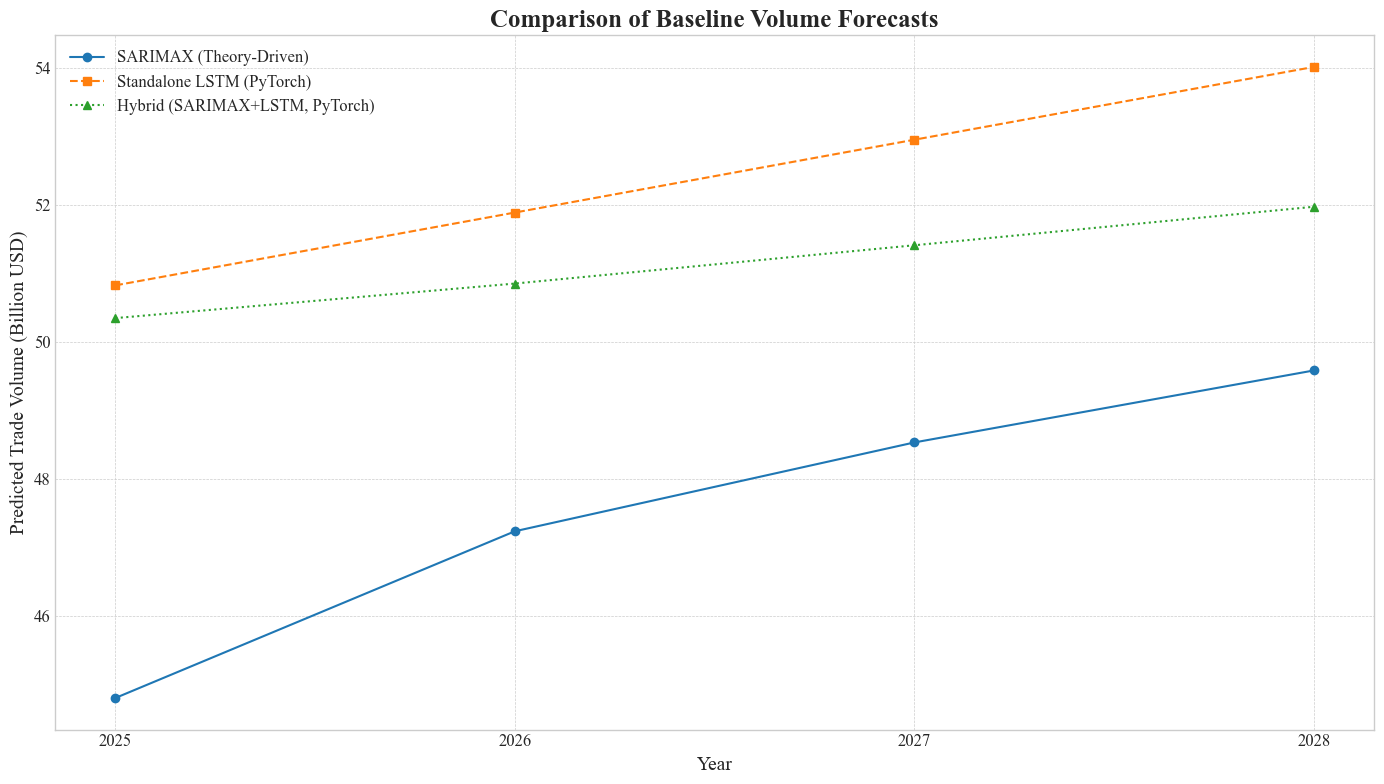


[SUCCESS] Final comparison Figure 14 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_14_Model_Comparison.png


In [26]:
# --- Cell 10: Final Comparison of All Three Models ---
# (This cell requires no changes and will work with the new PyTorch outputs)
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Step 10: Final Comparison of SARIMAX, LSTM, and Hybrid Models ---")

# 1. Get the SARIMAX annual forecast from our original model (Cells 4-5)
annual_forecast_sarimax = final_forecast_data[final_forecast_data['Type'] == 'Forecast']['Volume']
annual_forecast_sarimax.index = annual_forecast_sarimax.index.astype(int)

# 2. Combine all forecasts into one DataFrame
comparison_df = pd.DataFrame({
    'SARIMAX (Theory-Driven)': annual_forecast_sarimax,
    'Standalone LSTM (PyTorch)': annual_forecast_lstm,
    'Hybrid (SARIMAX+LSTM, PyTorch)': annual_forecast_hybrid
})
comparison_df = comparison_df.loc[2025:2028]

print("\n--- Annual Forecast Comparison Table (Billion USD) ---")
print(comparison_df.round(2))

# 3. Visualize the comparison
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(14, 8))
plt.plot(comparison_df.index, comparison_df['SARIMAX (Theory-Driven)'], marker='o', linestyle='-', label='SARIMAX (Theory-Driven)')
plt.plot(comparison_df.index, comparison_df['Standalone LSTM (PyTorch)'], marker='s', linestyle='--', label='Standalone LSTM (PyTorch)')
plt.plot(comparison_df.index, comparison_df['Hybrid (SARIMAX+LSTM, PyTorch)'], marker='^', linestyle=':', label='Hybrid (SARIMAX+LSTM, PyTorch)')
plt.title('Comparison of Baseline Volume Forecasts', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Predicted Trade Volume (Billion USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(comparison_df.index)
plt.tight_layout()
FIG_PATH_COMP = os.path.join(CLEAN_DIR, "Figure_14_Model_Comparison.png")
plt.savefig(FIG_PATH_COMP, dpi=300)
plt.show()

print(f"\n[SUCCESS] Final comparison Figure 14 saved to: {FIG_PATH_COMP}")


--- Step 11: Generating Professional-Grade Visualization for the Hybrid Model ---


C:\Users\ray\AppData\Local\Temp\ipykernel_6128\3341862383.py:35: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_hybrid_fit = hybrid_in_sample_fit_monthly.resample('Y').sum() / 1e3
C:\Users\ray\AppData\Local\Temp\ipykernel_6128\3341862383.py:38: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_actual_data = monthly_data['Trade_Volume'].resample('Y').sum() / 1e3


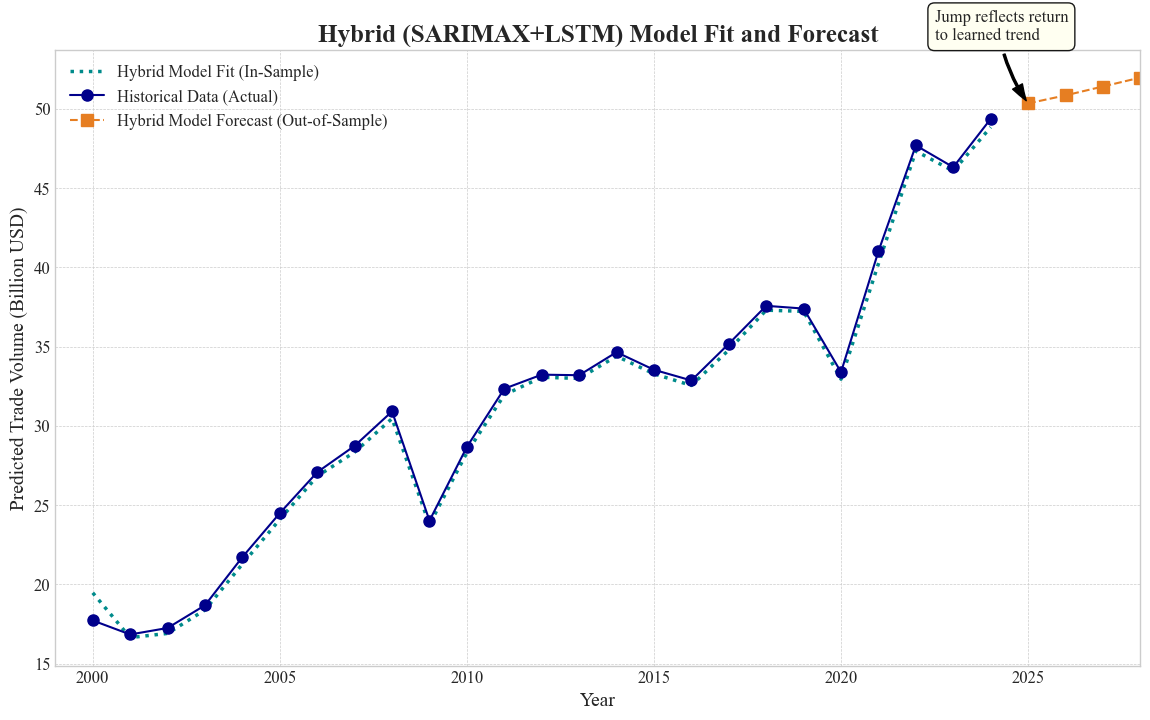


[SUCCESS] Final professional visualization for the Hybrid Model (Figure 15) saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_15_Hybrid_Model_Fit_Forecast_Final.png


In [27]:
# --- Cell 11 (FINAL VERSION): Professional Visualization with Annotation Fix ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- Step 11: Generating Professional-Grade Visualization for the Hybrid Model ---")

# (The data preparation part remains the same)
# ... [The code to calculate annual_hybrid_fit and hybrid_forecast_annual] ...
# ============================  FIX STARTS HERE ============================

# a) Get SARIMAX in-sample fitted values on monthly data
sarimax_in_sample_fit_monthly = sarimax_monthly.fittedvalues.dropna()

# b) Get LSTM in-sample predictions on the residuals
# **** 关键修正：为整个历史残差序列创建输入张量 X_resid ****
# 1. 先用所有残差创建序列
scaled_residuals_full = scaler_resid.transform(residuals.values.reshape(-1, 1))
resid_sequences_full = []
for i in range(len(scaled_residuals_full) - time_window_resid):
    resid_sequences_full.append((scaled_residuals_full[i:i+time_window_resid], scaled_residuals_full[i+time_window_resid:i+time_window_resid+1]))

# 2. 从序列创建 X_resid
X_resid = torch.FloatTensor([s[0] for s in resid_sequences_full])

lstm_resid_model.eval()
with torch.no_grad():
    in_sample_resid_pred_scaled = lstm_resid_model(X_resid)
# c) Inverse transform and align the residual predictions
in_sample_resid_pred = scaler_resid.inverse_transform(in_sample_resid_pred_scaled.numpy())
aligned_resid_pred = pd.Series(in_sample_resid_pred.flatten(), index=residuals.index[time_window_resid:])
# d) Combine to get the final hybrid in-sample fit
hybrid_in_sample_fit_monthly = sarimax_in_sample_fit_monthly.add(aligned_resid_pred, fill_value=0)
# e) Aggregate to annual level
annual_hybrid_fit = hybrid_in_sample_fit_monthly.resample('Y').sum() / 1e3
annual_hybrid_fit.index = annual_hybrid_fit.index.year
# Get the annual historical data for comparison
annual_actual_data = monthly_data['Trade_Volume'].resample('Y').sum() / 1e3
annual_actual_data.index = annual_actual_data.index.year
# Get the hybrid forecast from the comparison table
hybrid_forecast_annual = comparison_df['Hybrid (SARIMAX+LSTM, PyTorch)']


# --- Configure and Create the Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
colors = {
    'history': 'darkblue',
    'forecast': '#E67E22',
    'fit': 'darkcyan',
}

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(annual_hybrid_fit.index, annual_hybrid_fit.values, linestyle=':', linewidth=2.5, color=colors['fit'], label='Hybrid Model Fit (In-Sample)')
ax.plot(annual_actual_data.index, annual_actual_data.values, marker='o', markersize=8, linestyle='-', color=colors['history'], label='Historical Data (Actual)')
ax.plot(hybrid_forecast_annual.index, hybrid_forecast_annual.values, marker='s', markersize=8, linestyle='--', color=colors['forecast'], label='Hybrid Model Forecast (Out-of-Sample)')

# --- THE CRITICAL CHANGE: Improved Annotation Placement ---
first_fcst_year = hybrid_forecast_annual.index[0]
first_fcst_val = hybrid_forecast_annual.iloc[0]

# Position the text box to the left and slightly above the point it annotates
ax.annotate('Jump reflects return\nto learned trend',
            xy=(first_fcst_year, first_fcst_val),
            xytext=(first_fcst_year - 2.5, first_fcst_val + 4), # Adjusted coordinates
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, connectionstyle="arc3,rad=0.1"),
            fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="ivory", alpha=0.9))

# --- Final Formatting ---
ax.set_title('Hybrid (SARIMAX+LSTM) Model Fit and Forecast', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Predicted Trade Volume (Billion USD)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xlim(left=1999, right=2028) # Adjust x-axis for the new data range

FIG_PATH_HYBRID = os.path.join(CLEAN_DIR, "Figure_15_Hybrid_Model_Fit_Forecast_Final.png")
plt.savefig(FIG_PATH_HYBRID, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Final professional visualization for the Hybrid Model (Figure 15) saved to: {FIG_PATH_HYBRID}")